# Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.svm import OneClassSVM

# Carregando os Dados
df = pd.read_csv('data/anomaly_dataset.csv')
df.head()

,timestamp,mu,sigma,alpha,is_anomaly
0,733.457409,712.3766,4756.9228,-0.0212,0
1,733.507409,712.3991,4756.9196,-0.0212,0
2,733.557409,10.7841,5.8769,0.0001,0
3,733.607409,1.1596,4.7291,0.8860,0
4,733.657409,1.3216,4.2353,0.8987,0


## Ajuste do Ground Truth (Janela Deslizante)
O sensor de colisão do CARLA registra o impacto em um único frame. Como o algoritmo TNB avalia o comportamento do veículo em janelas de 50 frames, precisamos expandir o Ground Truth: se ocorreu uma colisão *dentro* da janela atual, toda a janela é considerada anômala.

In [8]:
# Expansão da flag de anomalia para cobrir a janela do TNB
WINDOW_SIZE = 50
df['gt_anomaly'] = df['is_anomaly'].rolling(window=WINDOW_SIZE, min_periods=1).max()

## Predição do TNB
No TNB, uma anomalia é detectada quando o desvio padrão estimado ($\hat{\sigma}$) ultrapassa um limite de alerta ($\sigma_{alert}$). Com base nos dados coletados, definiremos um threshold seguro.

In [9]:
# O sigma normal do seu log fica em ~2. O pico da batida passou de 20. 
# Usaremos 5.0 como limite de alerta (ajuste se necessário ao ver o gráfico).
SIGMA_ALERT = 5.0
df['tnb_pred'] = (df['sigma'] > SIGMA_ALERT).astype(int)

## Baseline: One-Class SVM
Para responder à exigência do revisor, implementamos o One-Class SVM como baseline padrão da literatura para detecção de anomalias, treinando-o com os dados iniciais de condução normal.

In [10]:
# Treinamos o SVM com os primeiros 200 frames (condução normal, sem batidas)
train_data = df[['mu', 'sigma', 'alpha']].iloc[:200]

oc_svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
oc_svm.fit(train_data)

# Predição do SVM (Retorna -1 para anomalia e 1 para normal. Convertendo para 1 e 0)
svm_preds = oc_svm.predict(df[['mu', 'sigma', 'alpha']])
df['svm_pred'] = (svm_preds == -1).astype(int)

## Resultados e Métricas
Comparação direta entre o TNB e o One-Class SVM utilizando as métricas solicitadas pelo revisor.

In [11]:
print("========== TNB (Temporal Naive Bayes) ==========")
print(classification_report(df['gt_anomaly'], df['tnb_pred'], target_names=['Normal', 'Anomaly']))
tnb_auc = roc_auc_score(df['gt_anomaly'], df['sigma'])
print(f"TNB ROC-AUC: {tnb_auc:.4f}\n")

print("========== One-Class SVM (Baseline) ==========")
print(classification_report(df['gt_anomaly'], df['svm_pred'], target_names=['Normal', 'Anomaly']))

========== TNB (Temporal Naive Bayes) ==========
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       334
     Anomaly       0.90      1.00      0.95        27

    accuracy                           0.99       361
   macro avg       0.95      1.00      0.97       361
weighted avg       0.99      0.99      0.99       361

TNB ROC-AUC: 0.9940

========== One-Class SVM (Baseline) ==========
              precision    recall  f1-score   support

      Normal       1.00      0.17      0.29       334
     Anomaly       0.09      1.00      0.16        27

    accuracy                           0.23       361
   macro avg       0.54      0.58      0.22       361
weighted avg       0.93      0.23      0.28       361



## Visualização do Salto Paramétrico
Gráfico demonstrando o comportamento do parâmetro $\sigma$ em relação ao Ground Truth de colisão.

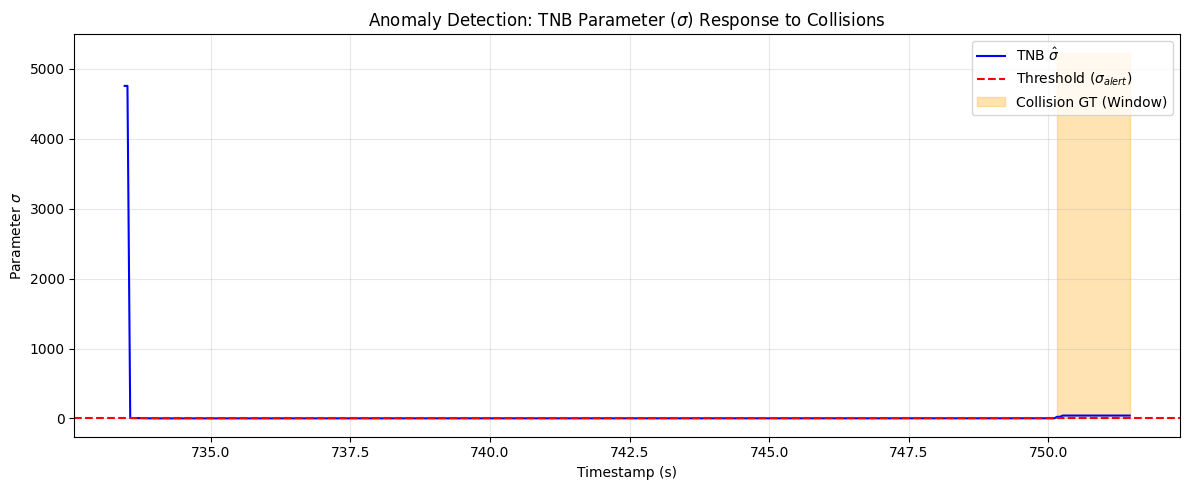

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'], df['sigma'], label=r'TNB $\hat{\sigma}$', color='blue', linewidth=1.5)
plt.axhline(SIGMA_ALERT, color='red', linestyle='--', label=r'Threshold ($\sigma_{alert}$)')

# Pinta o fundo de laranja exatamente onde ocorreu a anomalia (GT)
plt.fill_between(df['timestamp'], 0, df['sigma'].max() * 1.1, 
                 where=(df['gt_anomaly']==1), color='orange', alpha=0.3, label='Collision GT (Window)')

plt.title('Anomaly Detection: TNB Parameter ($\sigma$) Response to Collisions')
plt.xlabel('Timestamp (s)')
plt.ylabel(r'Parameter $\sigma$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Exportação para o TikZ  (LaTeX)

In [13]:
# Normaliza o tempo para começar do 0
df['time_norm'] = df['timestamp'] - df['timestamp'].iloc[0]

# Filtra apenas as colunas necessárias para o gráfico
df_tikz = df[['time_norm', 'sigma', 'gt_anomaly']].copy()

# Salva o CSV na pasta data
df_tikz.to_csv('data/anomaly_tikz_data.csv', index=False)
print("CSV para o TikZ exportado com sucesso!")

CSV para o TikZ exportado com sucesso!
